In [53]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import os

In [3]:
import os
import cv2
from PIL import Image

# ты запускаешь внутри "Mardu chanachum"
INPUT_DIR = "."
OUTPUT_DIR = "dataset_ready"

os.makedirs(OUTPUT_DIR, exist_ok=True)

FRAME_SKIP = 3
CROP_FACE = True

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

def save_face_or_frame(frame, output_folder, count):
    if CROP_FACE:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.3, 5)

        for (x, y, w, h) in faces:
            face = frame[y:y+h, x:x+w]
            cv2.imwrite(os.path.join(output_folder, f"img_{count}.jpg"), face)
            return 1
    else:
        cv2.imwrite(os.path.join(output_folder, f"img_{count}.jpg"), frame)
        return 1

    return 0


for person in os.listdir(INPUT_DIR):

    person_path = os.path.join(INPUT_DIR, person)

    if not os.path.isdir(person_path):
        continue

    print(f"\nProcessing: {person}")

    output_person = os.path.join(OUTPUT_DIR, person)
    os.makedirs(output_person, exist_ok=True)

    count = 0

    for file in os.listdir(person_path):

        file_path = os.path.join(person_path, file)

        # 📸 КАРТИНКИ
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            try:
                img = Image.open(file_path).convert("RGB")
                img.save(os.path.join(output_person, f"img_{count}.jpg"), "JPEG")
                count += 1
            except:
                print("Ошибка с изображением:", file)

        # 🎥 ВИДЕО
        elif file.lower().endswith((".mp4", ".avi", ".mov")):

            cap = cv2.VideoCapture(file_path)
            frame_id = 0

            while True:
                ret, frame = cap.read()
                if not ret:
                    break

                if frame_id % FRAME_SKIP == 0:
                    saved = save_face_or_frame(frame, output_person, count)
                    count += saved

                frame_id += 1

            cap.release()

    print(f"{person}: {count} файлов готово")


Processing: .ipynb_checkpoints
.ipynb_checkpoints: 0 файлов готово

Processing: Albert Akimyan
Albert Akimyan: 41 файлов готово

Processing: Albert Galstyan
Albert Galstyan: 39 файлов готово

Processing: Babken
Babken: 56 файлов готово

Processing: dataset_ready
dataset_ready: 0 файлов готово

Processing: Hrach
Hrach: 32 файлов готово

Processing: Mamikon
Mamikon: 53 файлов готово

Processing: Stepan
Stepan: 43 файлов готово


In [54]:
os.listdir('dataset_ready/')

['.ipynb_checkpoints',
 'Albert Akimyan',
 'Albert Galstyan',
 'Babken',
 'Hrach',
 'Mamikon',
 'Stepan']

In [55]:
labels =  {
 'Albert Akimyan':0,
 'Albert Galstyan':1,
 'Babken':2,
 'Hrach':3,
 'Mamikon':4,
 'Stepan':5}

In [56]:
def augment_image(image):
    augmented_images = []

    flipped = cv2.flip(image, 1)
    augmented_images.append(flipped)

    h, w = image.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), 15, 1)
    rotated = cv2.warpAffine(image, M, (w, h))
    augmented_images.append(rotated)

    brighter = cv2.convertScaleAbs(image, alpha=1.2, beta=30)
    augmented_images.append(brighter)

    darker = cv2.convertScaleAbs(image, alpha=0.8, beta=-30)
    augmented_images.append(darker)

    return augmented_images

In [57]:
X = []
y = []

for i in os.listdir('dataset_ready/'):

    if i == '.ipynb_checkpoints':
        continue

    for j in os.listdir(f'dataset_ready/{i}/'):
        try:
            image = cv2.imread(f'dataset_ready/{i}/{j}')
            
            if image is None:
                continue

            image = cv2.resize(image, (224,224))
            X.append(image)
            y.append(labels[i])
            aug_images = augment_image(image)
            for aug in aug_images:
                X.append(aug)
                y.append(labels[i])

        except :
            continue

X = np.array(X)
y = np.array(y)

In [58]:
X.shape

(1380, 224, 224, 3)

In [59]:
y.shape

(1380,)

In [60]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [61]:
num_classes = len(labels)

In [62]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=6)
y_test = to_categorical(y_test, num_classes=6)

In [63]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

In [64]:
datagen.fit(X_train)
train_generator = datagen.flow(
    X_train,
    y_train,
    batch_size=32
)

In [65]:
import tensorflow as tf 
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

In [66]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [67]:
for layer in base_model.layers:
    layer.trainable = False

In [74]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation = 'relu')(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs = base_model.input, outputs = output)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [75]:
history = model.fit(train_generator,validation_data=(X_test, y_test),epochs=25)

Epoch 1/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 297ms/step - accuracy: 0.4592 - loss: 1.4785 - val_accuracy: 0.8261 - val_loss: 0.8063
Epoch 2/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 272ms/step - accuracy: 0.6938 - loss: 0.8462 - val_accuracy: 0.7790 - val_loss: 0.6051
Epoch 3/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 272ms/step - accuracy: 0.7817 - loss: 0.6132 - val_accuracy: 0.9348 - val_loss: 0.3723
Epoch 4/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 272ms/step - accuracy: 0.8560 - loss: 0.4731 - val_accuracy: 0.9130 - val_loss: 0.3945
Epoch 5/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 275ms/step - accuracy: 0.8822 - loss: 0.4039 - val_accuracy: 0.9312 - val_loss: 0.3108
Epoch 6/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 277ms/step - accuracy: 0.8832 - loss: 0.3667 - val_accuracy: 0.9130 - val_loss: 0.3403
Epoch 7/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 276ms/step - accuracy: 0.8949 - loss: 0.3199 - val_accuracy: 0.9529 - val_loss: 0.2027
Epoch 8/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 297ms/step - accuracy: 0.9004 - loss: 0.3017 - val_accu

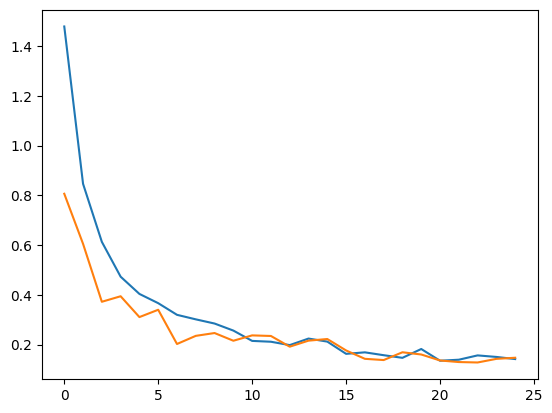

In [76]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

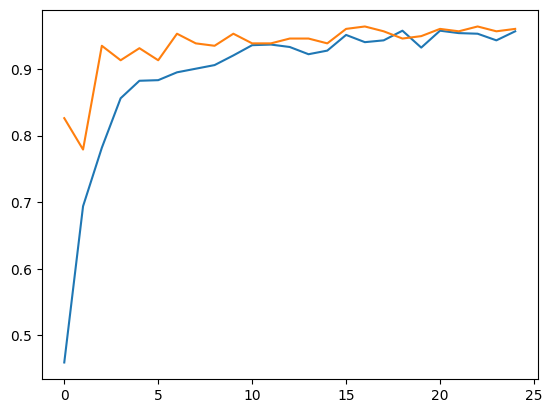

In [77]:
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])

In [78]:
import cv2
import numpy as np
import os

database = {}

for person in os.listdir('dataset_ready'):

    person_path = f'dataset_ready/{person}'
    
    if not os.path.isdir(person_path):
        continue

    encodings = []

    for img_name in os.listdir(person_path):
        img = cv2.imread(f"{person_path}/{img_name}")

        if img is None:
            continue

        img = cv2.resize(img, (100,100))
        img = img.flatten() / 255.0

        encodings.append(img)

    database[person] = encodings

In [79]:
def recognize(img_path):

    img = cv2.imread(img_path)

    if img is None:
        print("Ошибка")
        return

    img = cv2.resize(img, (100,100))
    img = img.flatten() / 255.0

    best_match = None
    min_dist = 999

    for person, enc_list in database.items():

        for enc in enc_list:

            dist = np.linalg.norm(enc - img)

            if dist < min_dist:
                min_dist = dist
                best_match = person

    print("Distance:", min_dist)

    if min_dist < 5:   # подбирается
        print("Найден:", best_match)
        return best_match
    else:
        print("Unknown")
        return "Unknown"

In [80]:
recognize("dataset_ready/Albert Galstyan/img_0.jpg")

Distance: 0.0
Найден: Albert Galstyan


'Albert Galstyan'

In [82]:
import pickle

with open("labels.pkl", "wb") as f:
    pickle.dump(labels, f)

print("labels сохранены")

labels сохранены


In [83]:
label_map = {v: k for k, v in labels.items()}